In [14]:
# Import required modules

import numpy as np          # Library for numerical operations such as array and matrix math
import pandas as pd          # Library for data manipulation using DataFrames and CSV reading
import matplotlib.pyplot as plt  # Library for creating plots and visualizations
import warnings
warnings.filterwarnings("ignore")  # Suppress warning messages to keep the output clean

In [15]:
# MNIST dataset downloaded from Kaggle : 
# https://www.kaggle.com/c/digit-recognizer/data

# Load the full MNIST dataset from the CSV file
# The dataset contains 42,000 rows (images) and 785 columns (1 label + 784 pixels)
d0 = pd.read_csv('mnist_train.csv')

print(d0.head(5)) # Print first 5 rows to preview the data structure

# Save the 'label' column into variable l
# Labels represent the actual digit (0-9) that each image shows
l = d0['label']

# Drop the 'label' column and keep only the pixel data (784 columns)
# Each row has 784 pixel values that form a 28x28 image when reshaped
d = d0.drop("label", axis=1)

   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0         

In [16]:
# Exercise: Perform the same analysis on all of 42K data-points
# The original notebook only used 15,000 points for time-efficiency
# Here we use the FULL dataset (all 42,000 samples) as requested by the exercise

labels = l    # All 42,000 labels (instead of l.head(15000))
data = d      # All 42,000 images (instead of d.head(15000))

print("the shape of sample data = ", data.shape)

the shape of sample data =  (42000, 784)


In [17]:
# Data-preprocessing: Standardizing the data
# StandardScaler transforms each feature to have mean=0 and standard deviation=1
# This is important because PCA is sensitive to the scale of features
# Without standardization, features with larger values would dominate the analysis

from sklearn.preprocessing import StandardScaler
standardized_data = StandardScaler().fit_transform(data)
print(standardized_data.shape)

(42000, 784)


In [18]:
# Find the covariance matrix: A^T * A
# The covariance matrix captures how each pair of features varies together
# Its shape is (784, 784) because we have 784 pixel features
sample_data = standardized_data

# Matrix multiplication using numpy to compute the covariance matrix
covar_matrix = np.matmul(sample_data.T, sample_data)

print("The shape of variance matrix = ", covar_matrix.shape)

The shape of variance matrix =  (784, 784)


In [19]:
# Finding the top two eigenvalues and corresponding eigenvectors
# for projecting onto a 2-Dimensional space
# eigh() returns eigenvalues in ascending order
# subset_by_index=[782,783] means we only compute the 2 largest eigenvalues (indices 782 and 783 out of 784)
# These correspond to the directions of maximum variance in the data

from scipy.linalg import eigh

values, vectors = eigh(covar_matrix, subset_by_index=[782,783])

print("Shape of eigen vectors = ", vectors.shape)

# Transpose eigenvectors from (784, 2) to (2, 784) for easier matrix multiplication later
vectors = vectors.T

print("Updated shape of eigen vectors = ", vectors.shape)
# vectors[1] = eigenvector for the 1st principal component (highest variance)
# vectors[0] = eigenvector for the 2nd principal component (second highest variance)

Shape of eigen vectors =  (784, 2)
Updated shape of eigen vectors =  (2, 784)


In [20]:
# Project the original data onto the plane formed by the two principal eigenvectors
# This reduces our data from 784 dimensions down to just 2 dimensions
# We multiply the eigenvectors (2, 784) by the data transposed (784, 42000)
# Result: (2, 42000) — each data point now has only 2 coordinates

new_coordinates = np.matmul(vectors, sample_data.T)

print("Resultant new data points' shape ", vectors.shape, "X", sample_data.T.shape, " = ", new_coordinates.shape)

Resultant new data points' shape  (2, 784) X (784, 42000)  =  (2, 42000)


In [21]:
# Append the labels to the 2D projected data so we can color-code the plot
# np.vstack stacks the 2 coordinate rows + 1 label row, then we transpose to get (42000, 3)
new_coordinates = np.vstack((new_coordinates, labels)).T

# Create a DataFrame with columns for the 2 principal components and the label
dataframe = pd.DataFrame(data=new_coordinates, columns=("1st_principal", "2nd_principal", "label"))
print(dataframe.head())

   1st_principal  2nd_principal  label
0      -5.226445      -5.140478    1.0
1       6.032996      19.292332    0.0
2      -1.705813      -7.644503    1.0
3       5.836139      -0.474207    4.0
4       6.024818      26.559574    0.0


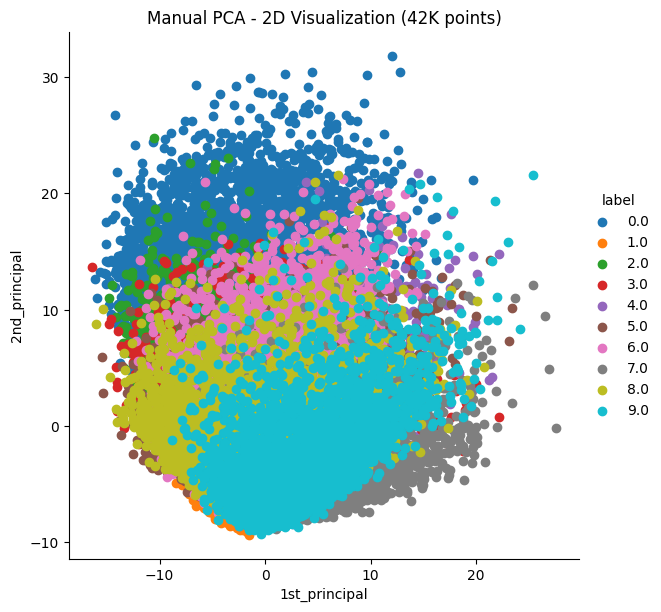

In [22]:
# Plot the 2D PCA projection using manual eigenvector computation
# Each digit (0-9) is shown in a different color using the 'hue' parameter
# FacetGrid creates a scatter plot where we can visually see how well PCA separates the digits
import seaborn as sn

sn.FacetGrid(dataframe, hue="label", height=6).map(plt.scatter, '1st_principal', '2nd_principal').add_legend()
plt.title('Manual PCA - 2D Visualization (42K points)')
plt.show()

# PCA using Scikit-Learn

In [23]:
# PCA using Scikit-Learn (simpler than the manual approach above)
# Scikit-Learn handles the covariance matrix, eigenvalues, and projection internally
from sklearn import decomposition

pca = decomposition.PCA()

# Set number of components to 2 for 2D visualization
pca.n_components = 2
pca_data = pca.fit_transform(sample_data)

print("shape of pca_reduced.shape = ", pca_data.shape)

shape of pca_reduced.shape =  (42000, 2)


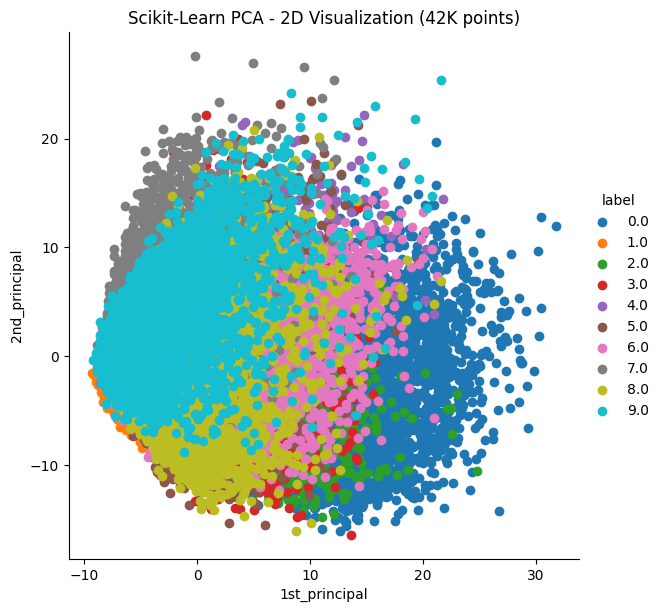

In [24]:
# Attach labels to the 2D PCA data and plot it
# This should produce a very similar result to the manual PCA above
# We use a separate variable (pca_with_labels) to avoid issues if this cell is re-run
import seaborn as sn

pca_with_labels = np.vstack((pca_data.T, labels)).T

pca_df = pd.DataFrame(data=pca_with_labels, columns=("1st_principal", "2nd_principal", "label"))
sn.FacetGrid(pca_df, hue="label", height=6).map(plt.scatter, '1st_principal', '2nd_principal').add_legend()
plt.title('Scikit-Learn PCA - 2D Visualization (42K points)')
plt.show()

# PCA for dimensionality reduction (not for visualization)

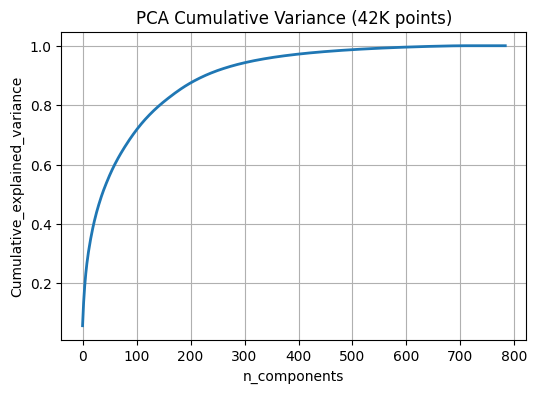

In [25]:
# PCA for dimensionality reduction (non-visualization)
# Here we use all 784 components to analyze how much variance each component explains
# This helps us decide how many dimensions we actually need to keep

pca.n_components = 784
pca_data_full = pca.fit_transform(sample_data)

# Calculate the percentage of variance explained by each principal component
# We divide each component's variance by the total variance to get a ratio
percentage_var_explained = pca.explained_variance_ / np.sum(pca.explained_variance_)

# Cumulative sum shows the total variance explained as we add more components
# For example, cum_var_explained[199] tells us how much variance the first 200 components explain
cum_var_explained = np.cumsum(percentage_var_explained)

# Plot the PCA spectrum (cumulative explained variance vs number of components)
plt.figure(1, figsize=(6, 4))
plt.clf()
plt.plot(cum_var_explained, linewidth=2)
plt.axis('tight')
plt.grid()
plt.xlabel('n_components')
plt.ylabel('Cumulative_explained_variance')
plt.title('PCA Cumulative Variance (42K points)')
plt.show()

# If we take 200 dimensions, approx. 90% of variance is explained
# This means we can reduce from 784 to ~200 dimensions and still keep most of the information

# t-SNE using Scikit-Learn (42K points)

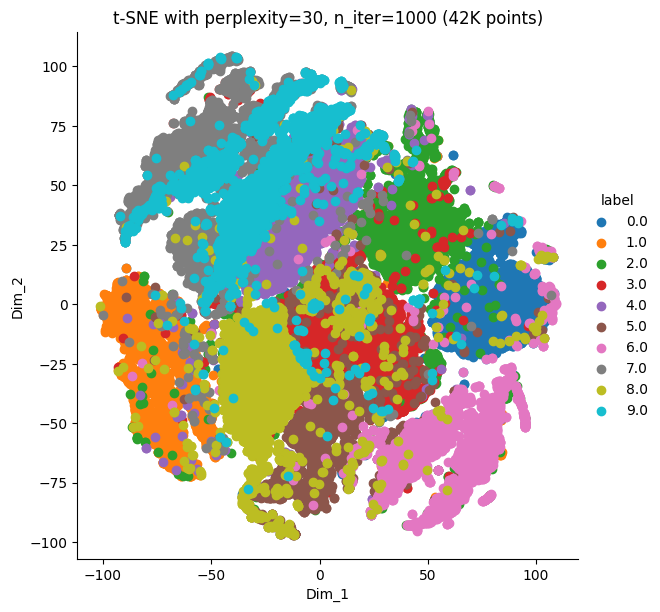

In [26]:
# t-SNE (t-distributed Stochastic Neighbor Embedding) with ALL 42K points
# Unlike PCA (which is linear), t-SNE is a non-linear technique that preserves local structure
# It is especially good at visualizing clusters in high-dimensional data
#
# The original notebook only used 1,000 points because t-SNE is computationally expensive
# Here we use all 42,000 points as requested by the exercise
#
# NOTE: This will take significantly longer to run than with 1,000 points
# Default parameters: perplexity=30, learning_rate=200, n_iter=1000

from sklearn.manifold import TSNE

# Using all 42K standardized data points
data_full = standardized_data
labels_full = labels

# t-SNE with default perplexity=30, n_iter=1000
model = TSNE(n_components=2, random_state=0)

tsne_data = model.fit_transform(data_full)

# Create a DataFrame for plotting: stack the 2D coordinates with labels
tsne_with_labels = np.vstack((tsne_data.T, labels_full)).T
tsne_df = pd.DataFrame(data=tsne_with_labels, columns=("Dim_1", "Dim_2", "label"))

# Plot the t-SNE result — each digit should form a distinct cluster
sn.FacetGrid(tsne_df, hue="label", height=6).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()
plt.title('t-SNE with perplexity=30, n_iter=1000 (42K points)')
plt.show()

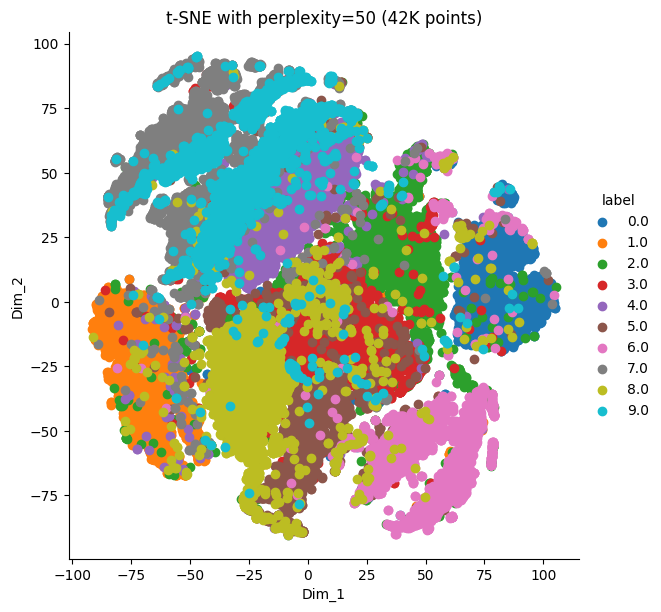

In [27]:
# t-SNE with perplexity=50
# Perplexity controls how many neighbors each point considers
# Higher perplexity = considers more neighbors = captures more global structure
# Lower perplexity = focuses on local structure = tighter, smaller clusters
# Typical values range from 5 to 50

model = TSNE(n_components=2, random_state=0, perplexity=50)
tsne_data = model.fit_transform(data_full)

tsne_with_labels = np.vstack((tsne_data.T, labels_full)).T
tsne_df = pd.DataFrame(data=tsne_with_labels, columns=("Dim_1", "Dim_2", "label"))

sn.FacetGrid(tsne_df, hue="label", height=6).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()
plt.title('t-SNE with perplexity=50 (42K points)')
plt.show()

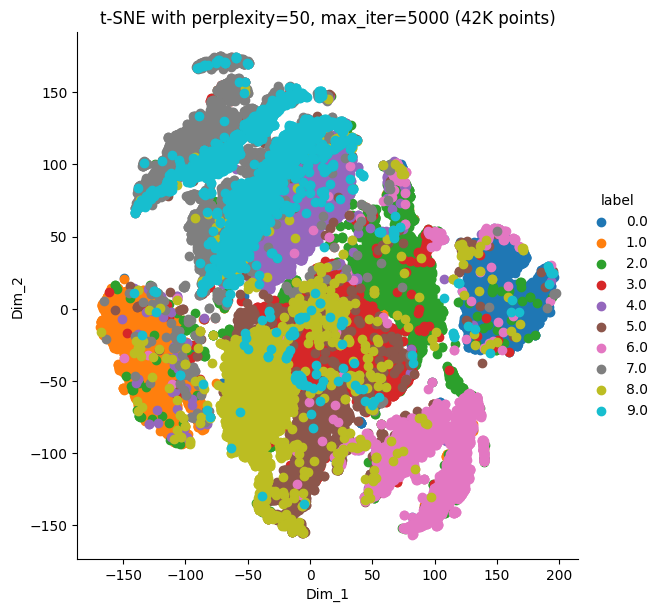

In [29]:
# t-SNE with perplexity=50 and max_iter=5000
# max_iter controls the number of optimization iterations
# More iterations allow the algorithm to converge better and produce cleaner clusters
# Default is 1000, here we increase to 5000 to see if the clusters become more defined

model = TSNE(n_components=2, random_state=0, perplexity=50, max_iter=5000)
tsne_data = model.fit_transform(data_full)

tsne_with_labels = np.vstack((tsne_data.T, labels_full)).T
tsne_df = pd.DataFrame(data=tsne_with_labels, columns=("Dim_1", "Dim_2", "label"))

sn.FacetGrid(tsne_df, hue="label", height=6).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()
plt.title('t-SNE with perplexity=50, max_iter=5000 (42K points)')
plt.show()

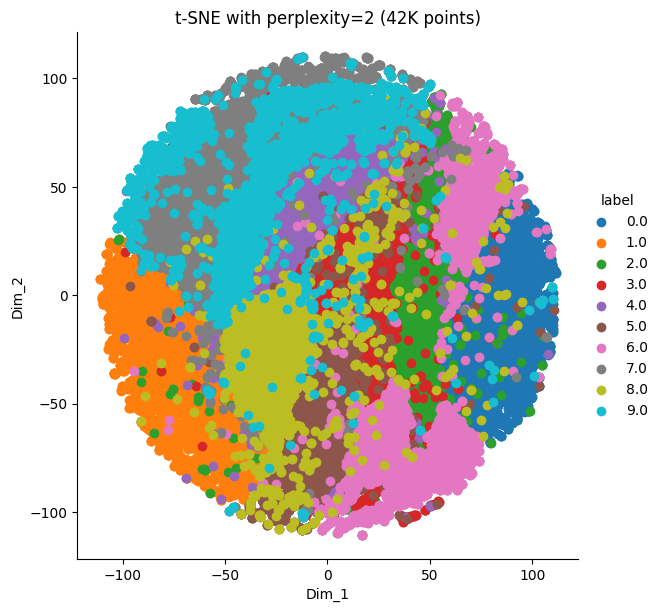

In [30]:
# t-SNE with perplexity=2
# Very low perplexity means the algorithm only considers ~2 nearest neighbors
# This produces many small, fragmented clusters instead of well-defined groups
# It is useful to compare against higher perplexity values to understand the effect
# of this hyperparameter on the visualization

model = TSNE(n_components=2, random_state=0, perplexity=2)
tsne_data = model.fit_transform(data_full)

tsne_with_labels = np.vstack((tsne_data.T, labels_full)).T
tsne_df = pd.DataFrame(data=tsne_with_labels, columns=("Dim_1", "Dim_2", "label"))

sn.FacetGrid(tsne_df, hue="label", height=6).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()
plt.title('t-SNE with perplexity=2 (42K points)')
plt.show()